# Introduction
This project **(Midterm #2)** is a direct continuation of the first part (**Midterm #1: Spotify Hit Predictor**). In the first midterm, the focus is on baseline models (such as linear regression, SVM, and tree algorithms), which will be further refined through deep hyperparameter tuning to maximize their effectiveness.

The current stage (**Midterm #2**) is fully focused on using ***Neural Networks*** (NN) to solve the same problem — predicting track_popularity (track popularity). The use of Deep Learning approaches is aimed at extracting more complex nonlinear dependencies (non-linear patterns) from audio features and metadata. The main task is to build the correct architecture of a fully connected neural network (feed—forward neural network), avoid overfitting on sparse data (sparse data) and compare the final performance with the configured basic models from the first part.

# 0. Imports & Setup

In [41]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings 
warnings.filterwarnings('ignore')

# 1. Load data and Preview

In [2]:
df = pd.read_csv('data/spotify_songs_ready.csv')

In [5]:
pd.set_option('display.max_columns', None)
df.head()

,Unnamed: 0,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,song_age,duration_min,vibe,g_edm,g_latin,g_pop,g_r&b,g_rap,g_rock,subg_album rock,subg_big room,subg_classic rock,subg_dance pop,subg_electro house,subg_electropop,subg_gangster rap,subg_hard rock,subg_hip hop,subg_hip pop,subg_indie poptimism,subg_latin hip hop,subg_latin pop,subg_neo soul,subg_new jack swing,subg_permanent wave,subg_pop edm,subg_post-teen pop,subg_progressive electro house,subg_reggaeton,subg_southern hip hop,subg_trap,subg_tropical,subg_urban contemporary
0,0,66,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,2.0,3.245900,0.685168,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,1,67,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,2.0,2.710000,0.591690,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,2,70,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,2.0,2.943600,0.628425,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,3,60,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,2.0,2.818217,0.667740,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,4,69,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,2.0,3.150867,0.541450,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32828 entries, 0 to 32827
Data columns (total 46 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unnamed: 0                      32828 non-null  int64  
 1   track_popularity                32828 non-null  int64  
 2   danceability                    32828 non-null  float64
 3   energy                          32828 non-null  float64
 4   key                             32828 non-null  int64  
 5   loudness                        32828 non-null  float64
 6   mode                            32828 non-null  int64  
 7   speechiness                     32828 non-null  float64
 8   acousticness                    32828 non-null  float64
 9   instrumentalness                32828 non-null  float64
 10  liveness                        32828 non-null  float64
 11  valence                         32828 non-null  float64
 12  tempo                           

# 2. Exploratory Data Analysis

In [21]:
# Settings 
sns.set_theme(style="whitegrid", context="paper")

target = 'track_popularity'
bool_features = [col for col in df.columns if df[col].dtype == 'bool']
continuous_features = [col for col in df.columns if df[col].dtype in ['float64', 'int64'] and col != target]

Text(0.5, 1.0, 'Target Distribution')

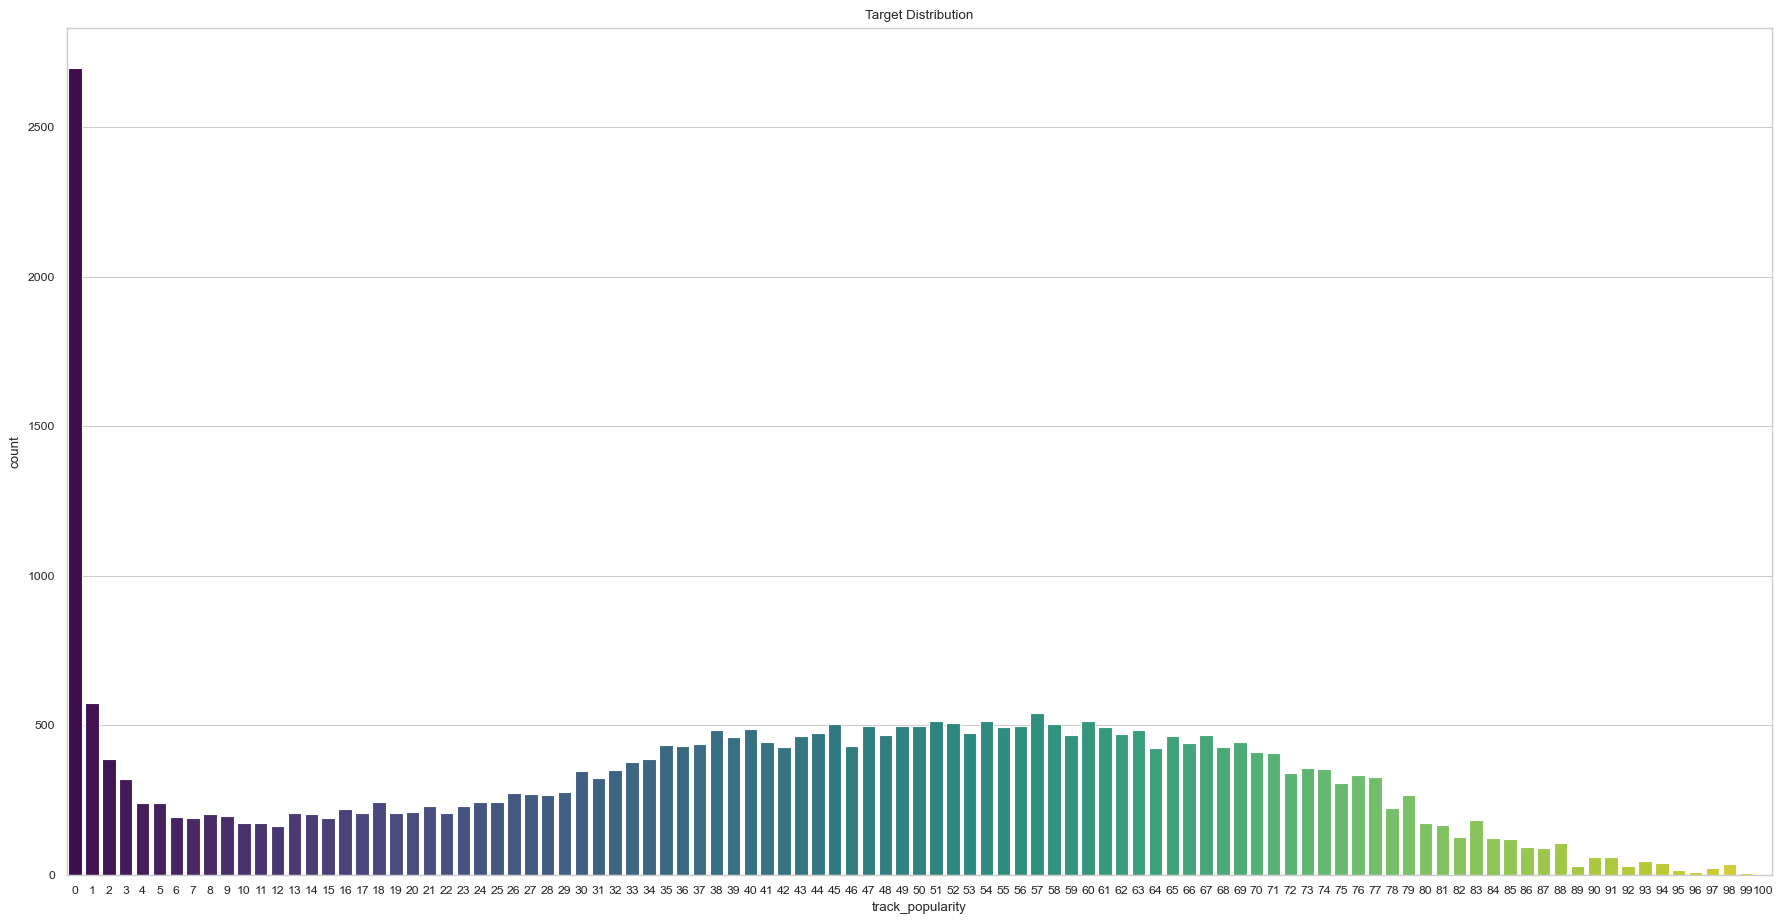

In [24]:
plt.figure(figsize=(22, 11))
sns.countplot(x=df['track_popularity'], palette='viridis')
plt.title("Target Distribution")

Text(0, 0.5, 'Frequency')

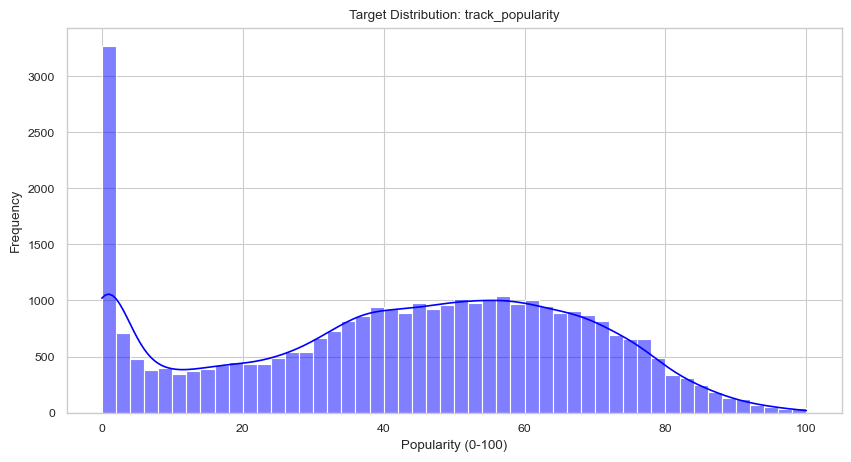

In [26]:
plt.figure(figsize=(10, 5))
sns.histplot(df[target], bins=50, kde=True, color='blue')
plt.title('Target Distribution: track_popularity')
plt.xlabel('Popularity (0-100)')
plt.ylabel('Frequency')

### Continuous Features Distributions & Skewness

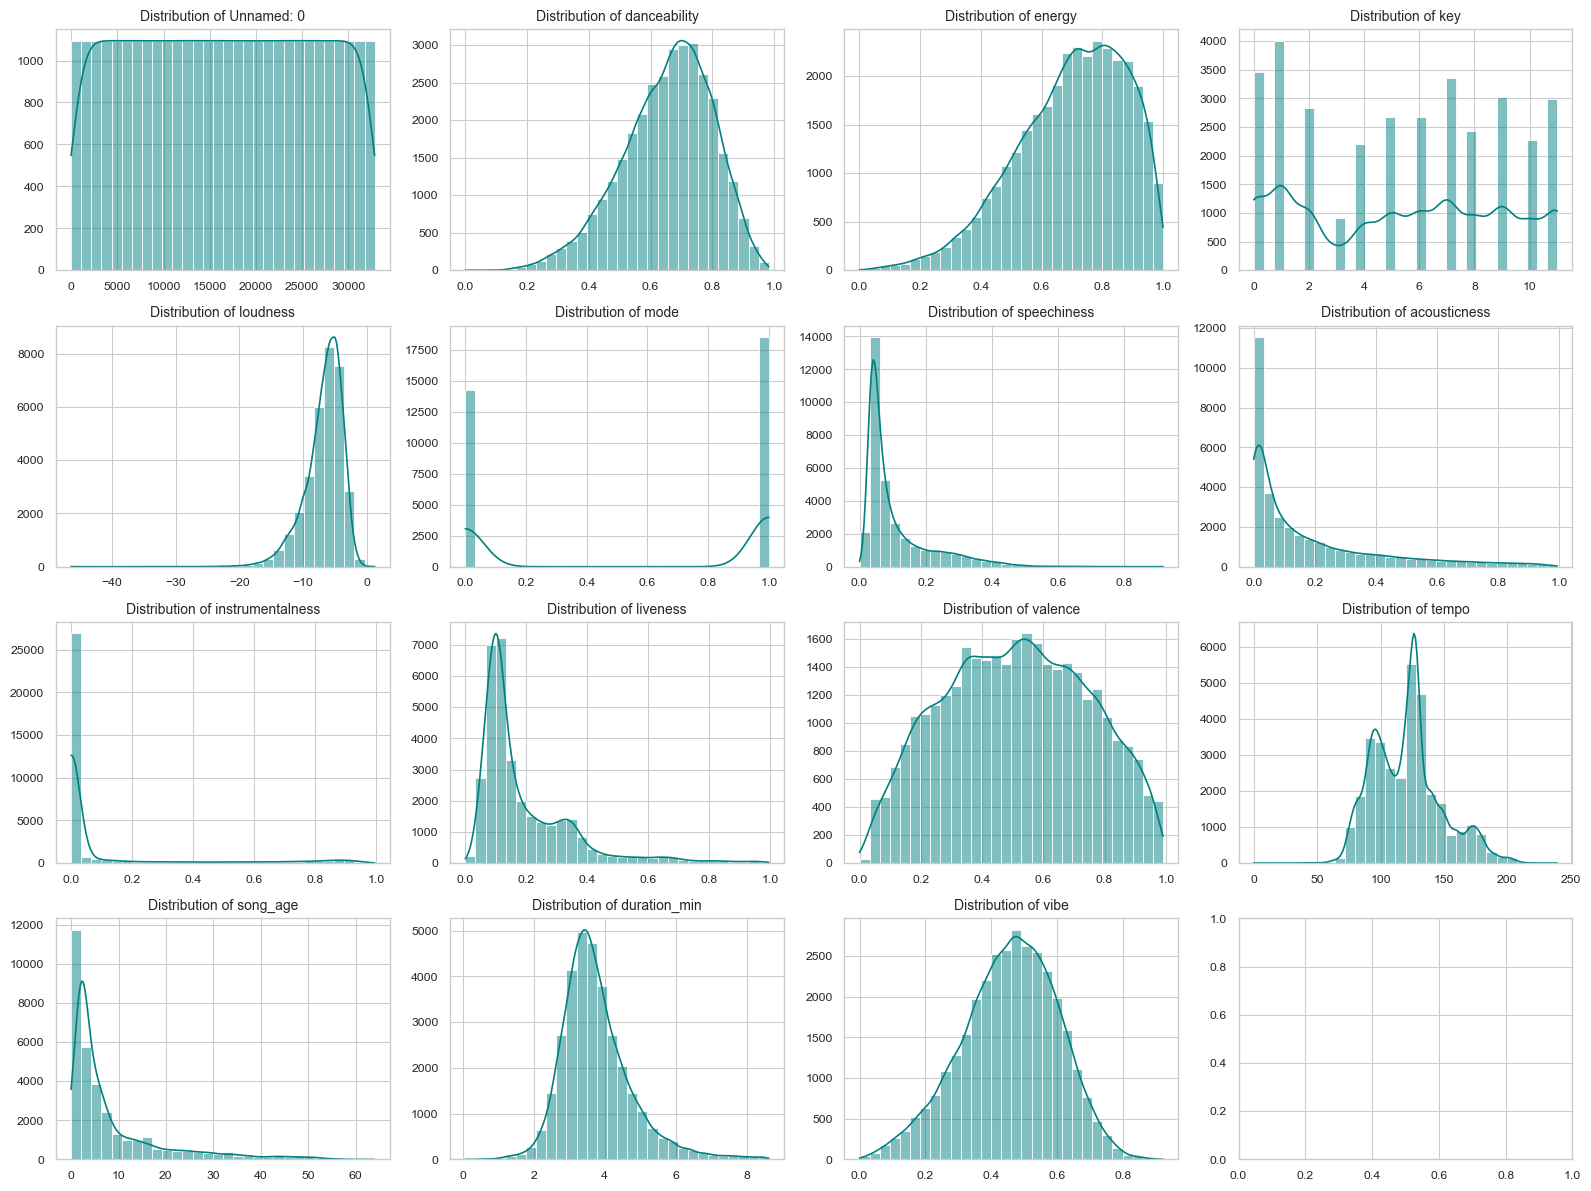

In [27]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(continuous_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal', bins=30)
    axes[i].set_title(f'Distribution of {col}', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()

### Outliers Detection

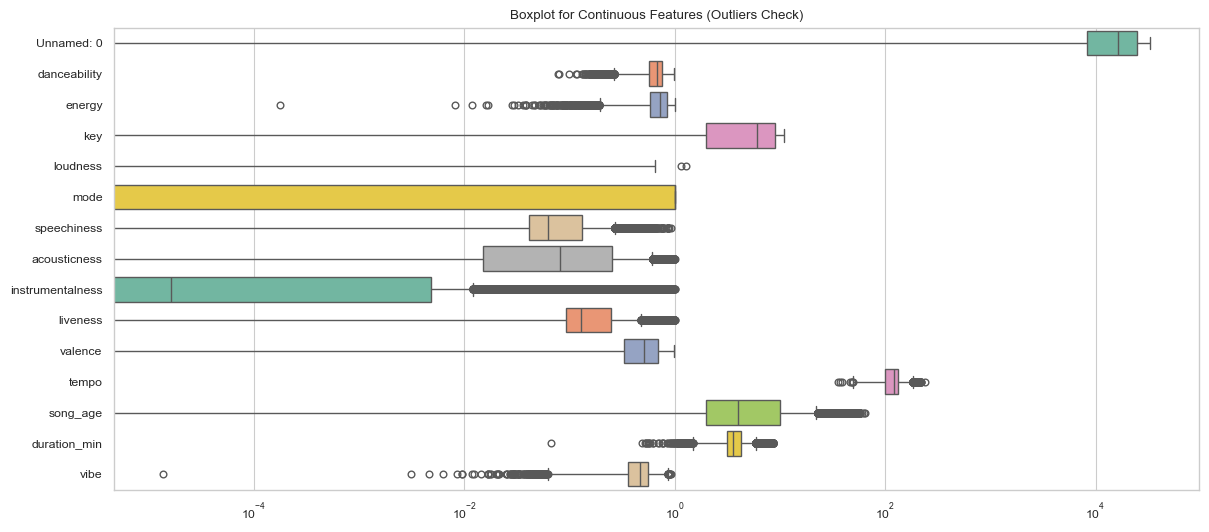

In [28]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[continuous_features], orient="h", palette="Set2")
plt.title('Boxplot for Continuous Features (Outliers Check)')
plt.xscale('log')

### Sparsity Check for Boolean Features

Text(0, 0.5, 'Genre / Subgenre')

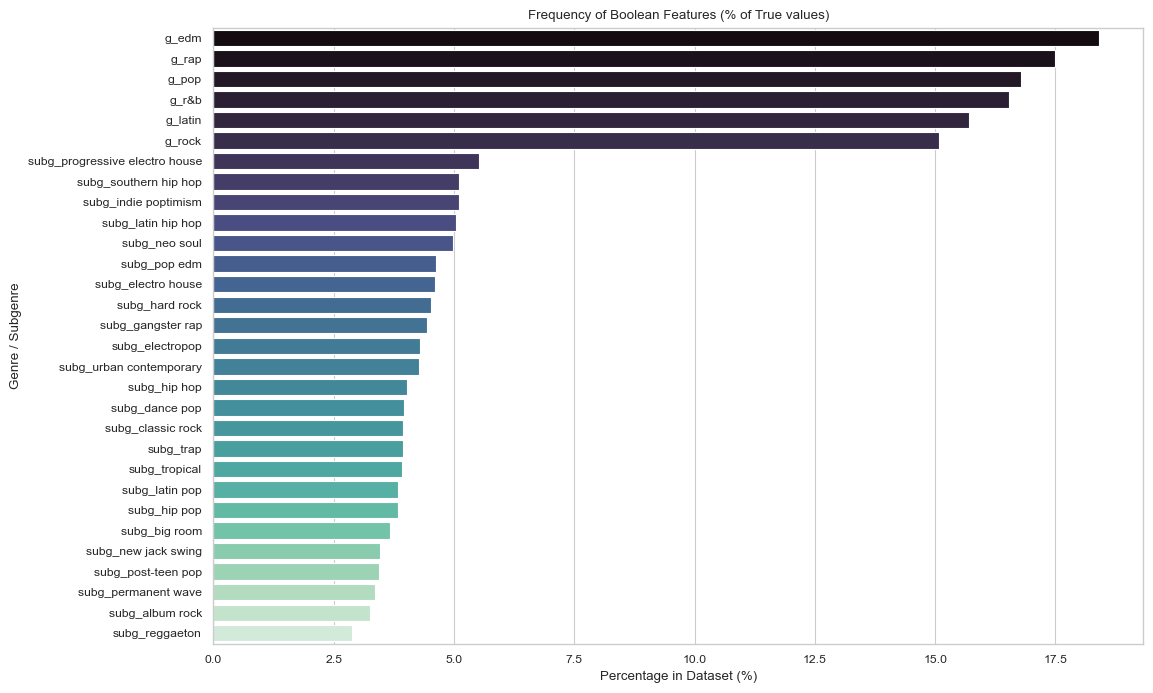

In [29]:
sparsity_df = (df[bool_features].mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=sparsity_df.values, y=sparsity_df.index, palette="mako")
plt.title('Frequency of Boolean Features (% of True values)')
plt.xlabel('Percentage in Dataset (%)')
plt.ylabel('Genre / Subgenre')

### Correlation Heatmap

Text(0.5, 1.0, 'Spearman Correlation Matrix (Continuous Features)')

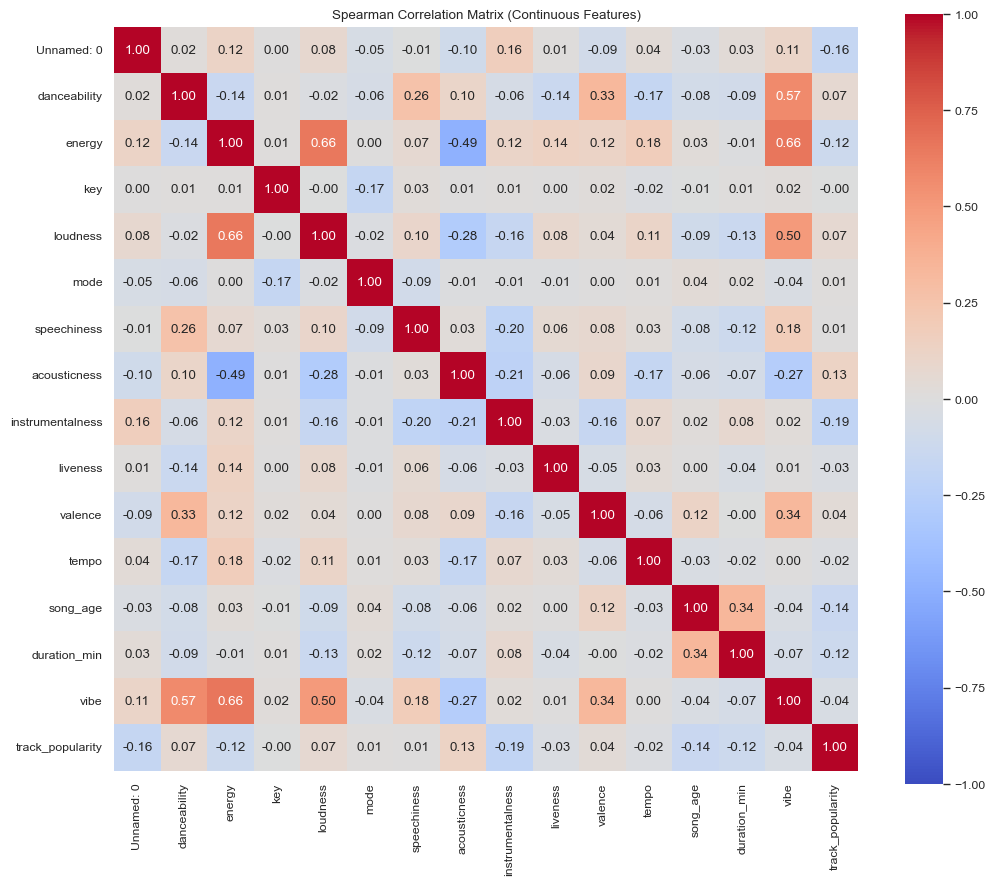

In [32]:
plt.figure(figsize=(12, 10))
corr_matrix = df[continuous_features + [target]].corr(method='spearman')

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Spearman Correlation Matrix (Continuous Features)')

## Modeling

In [36]:
X = df.drop(columns=['track_popularity'])
y = df['track_popularity']

In [38]:
X_temp, X_test,  y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)

In [39]:
# Feature Scaling 
countinuous_features = [col for col in X.columns if X[col].dtype in ['float62', 'int62']]
bool_features = [col for col in X.columns if X[col].dtype == 'bool']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[continuous_features] = scaler.fit_transform(X_train[continuous_features])
X_val_scaled[continuous_features] = scaler.transform(X_val[continuous_features])
X_test_scaled[continuous_features] = scaler.transform(X_test[continuous_features])

# Convertation bool to float32 for TensorFlow 
X_train_scaled[bool_features] = X_train_scaled[bool_features].astype('float32')
X_val_scaled[bool_features] = X_val_scaled[bool_features].astype('float32')
X_test_scaled[bool_features] = X_test_scaled[bool_features].astype('float32')


In [75]:
# NN Architecture 

input_dim = X_train_scaled.shape[1]

model = Sequential([
    Dense(256, activation='relu', input_shape=(input_dim, )),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(1, activation='linear')
])

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 256)            │        11,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 32)             │         2,08

 Total params: 142,081 (555.00 KB)

 Trainable params: 139,841 (546.25 KB)

 Non-trainable params: 2,240 (8.75 KB)

In [76]:
# Compilation
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='MSE', metrics=['mse', 'RootMeanSquaredError'])


In [71]:
# Callbacks

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20, 
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor= 0.2, 
    patience=5, 
    min_lr=1e-5
)

In [77]:
# Model Training 

history = model.fit(
    X_train_scaled, y_train, 
    validation_data = (X_val_scaled, y_val),
    epochs = 200, 
    batch_size = 64, 
    callbacks = [early_stopping, reduce_lr],
    verbose = 1
)

Epoch 1/200
329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - RootMeanSquaredError: 47.1831 - loss: 2226.2427 - mse: 2226.2427 - val_RootMeanSquaredError: 44.0165 - val_loss: 1937.4557 - val_mse: 1937.4557 - learning_rate: 0.0010
Epoch 2/200
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - RootMeanSquaredError: 37.7188 - loss: 1422.7106 - mse: 1422.7106 - val_RootMeanSquaredError: 30.1828 - val_loss: 911.0042 - val_mse: 911.0042 - learning_rate: 0.0010
Epoch 3/200
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - RootMeanSquaredError: 27.2920 - loss: 744.8509 - mse: 744.8509 - val_RootMeanSquaredError: 23.7644 - val_loss: 564.7468 - val_mse: 564.7468 - learning_rate: 0.0010
Epoch 4/200
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - RootMeanSquaredError: 24.3439 - loss: 592.6269 - mse: 592.6269 - val_RootMeanSquaredError: 22.5856 - val_loss: 510.1112 - val_mse: 510.1112 - learning_rate: 0.0010
Epoch 5/200
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - RootMeanSquaredError: 24.1587 - loss: 583.6415 - mse: 583.6415 

In [81]:
print(history.history.keys())

dict_keys(['RootMeanSquaredError', 'loss', 'mse', 'val_RootMeanSquaredError', 'val_loss', 'val_mse', 'learning_rate'])


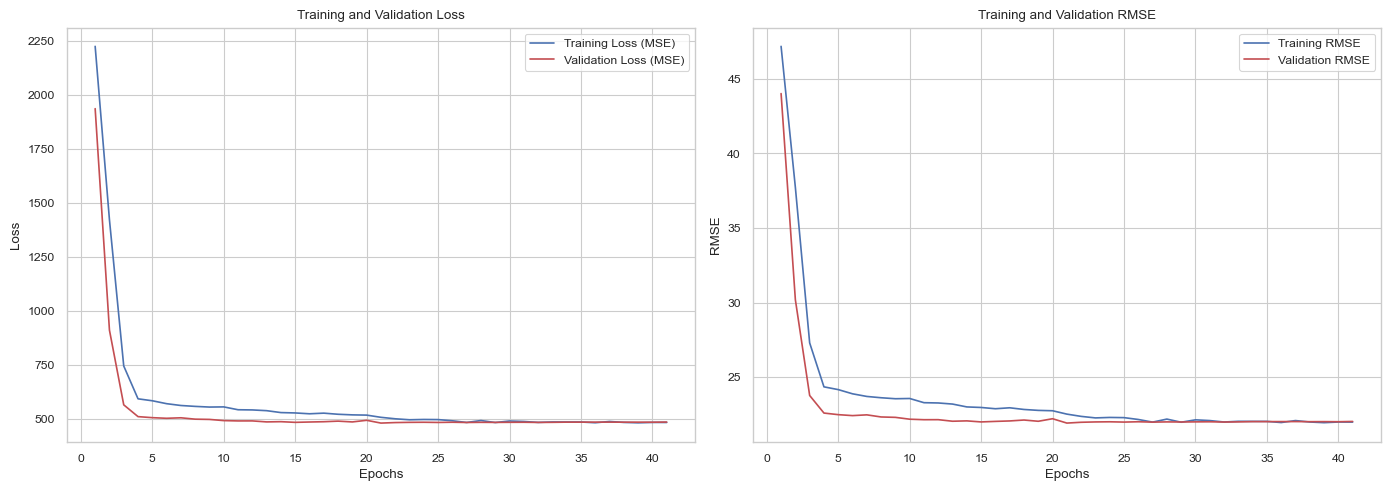

In [ ]:
def plot_learning_curves(history):
    hist = history.history
    
    loss = hist['loss']
    val_loss = hist['val_loss']
    
    rmse = hist['RootMeanSquaredError']
    val_rmse = hist['val_RootMeanSquaredError']
    
    epochs = range(1, len(loss) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # MSE
    ax1.plot(epochs, loss, 'b-', label='Training Loss (MSE)')
    ax1.plot(epochs, val_loss, 'r-', label='Validation Loss (MSE)')
    ax1.set_title('Training and Validation Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    # RMSE
    ax2.plot(epochs, rmse, 'b-', label='Training RMSE')
    ax2.plot(epochs, val_rmse, 'r-', label='Validation RMSE')
    ax2.set_title('Training and Validation RMSE')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('RMSE')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

# Вызов функции для отрисовки графиков
plot_learning_curves(history)